In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
average_sales_per_day = 503.68
df = pd.read_csv("olist_orders_dataset.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['hour'] = df['order_purchase_timestamp'].dt.hour
orders_per_day_hour = df.groupby([
    df['order_purchase_timestamp'].dt.date, 
    'hour'
]).size()

avg_orders_per_hour = orders_per_day_hour.groupby('hour').mean()

In [4]:
#Dates min/ max
print(df['order_purchase_timestamp'].min())
print(df['order_purchase_timestamp'].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


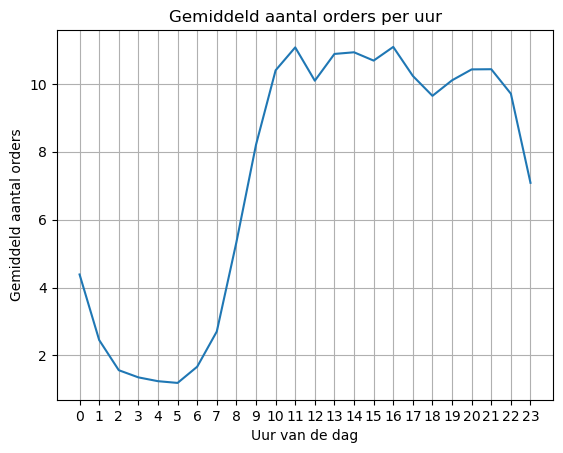

In [5]:
avg_orders_per_hour = (df.assign(
        date=df['order_purchase_timestamp'].dt.date,
        hour=df['order_purchase_timestamp'].dt.hour
    ).groupby(['date', 'hour']).size().groupby('hour').mean())

plt.figure()
avg_orders_per_hour.plot(kind='line')
plt.xlabel("Uur van de dag")
plt.ylabel("Gemiddeld aantal orders")
plt.title("Gemiddeld aantal orders per uur")
plt.xticks(range(0, 24))
plt.grid()
plt.show()

In [6]:
pdf = avg_orders_per_hour / avg_orders_per_hour.sum()

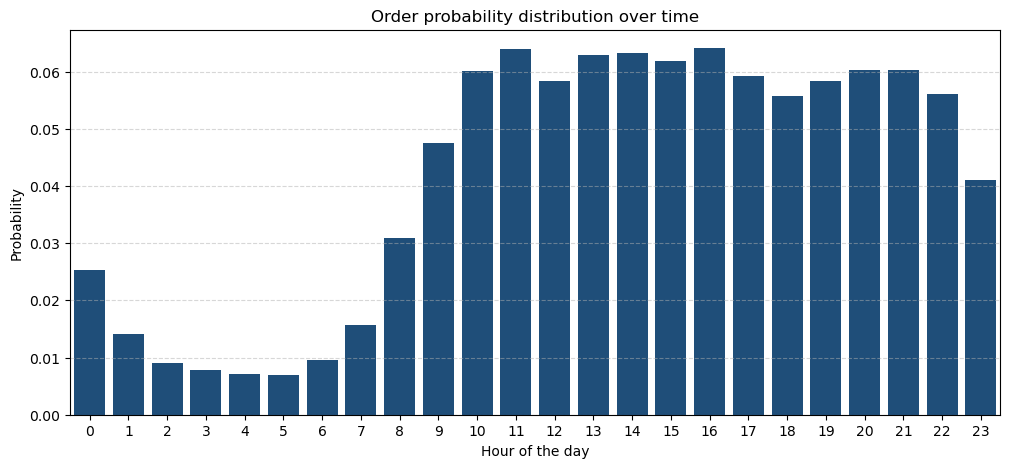

In [7]:
plt.figure(figsize=(12, 5))
plt.bar(pdf.index, pdf.values,  color="#1f4e79")
plt.xlabel("Hour of the day")
plt.ylabel("Probability")
plt.title("Order probability distribution over time")
plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


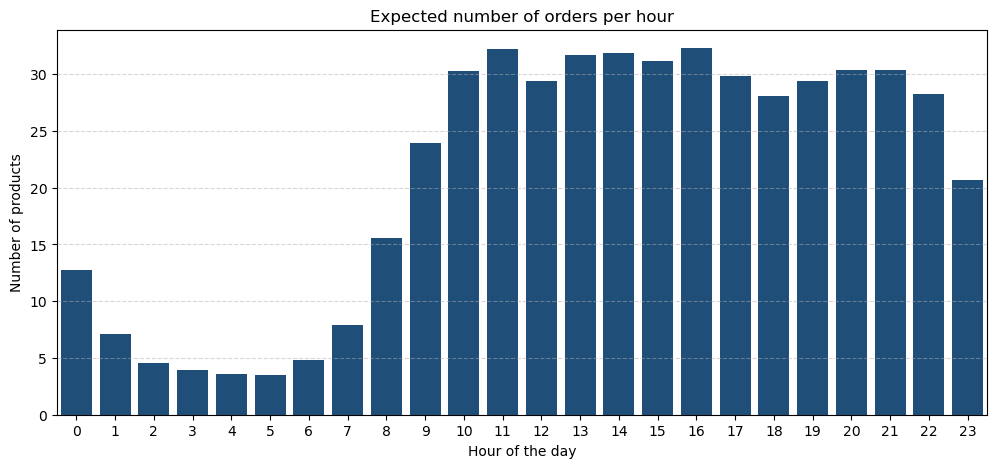

In [8]:
expected_products_per_hour = pdf * average_sales_per_day

plt.figure(figsize=(12, 5))
plt.bar(expected_products_per_hour.index, expected_products_per_hour.values, color="#1f4e79")
plt.xlabel("Hour of the day")
plt.ylabel("Number of products")
plt.title("Expected number of orders per hour")
plt.xlim(-0.5, 23.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.show()

In [9]:
expected_products_per_hour

hour
0     12.773728
1      7.145846
2      4.557627
3      3.942385
4      3.615308
5      3.466466
6      4.858737
7      7.881935
8     15.546367
9     23.911100
10    30.295444
11    32.262171
12    29.402815
13    31.701054
14    31.842779
15    31.129933
16    32.302858
17    29.811705
18    28.105125
19    29.438174
20    30.373917
21    30.389306
22    28.286795
23    20.638424
dtype: float64